# Breast Cancer Classification with Machine Learning

This project explores the Breast Cancer Wisconsin dataset and builds machine learning models to classify tumors as **malignant** or **benign** based on cellular features extracted from medical images.

The analysis includes:

- Exploratory Data Analysis (EDA)
- Visualization of tumor characteristics
- Training machine learning models
- Evaluating model performance

## 1. Load Required Libraries

In this section we import the Python libraries required for data analysis and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

## 2. Load the Breast Cancer Dataset

The dataset is provided by scikit-learn and contains measurements computed from digitized images of breast mass samples.

Each sample is labeled as:

- **Malignant (0)**
- **Benign (1)**

The goal is to build a model that can predict the diagnosis based on these measurements.

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

df = pd.concat([X, y], axis=1)

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Dataset Overview

Before building a machine learning model, we explore the structure of the dataset.

We will check:

- number of samples
- number of features
- target distribution

In [3]:
df.shape

(569, 31)

### Target Distribution

We inspect how many samples belong to each diagnostic class.

In [4]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

### Visualization of Tumor Classes

We plot the distribution of benign and malignant tumors.

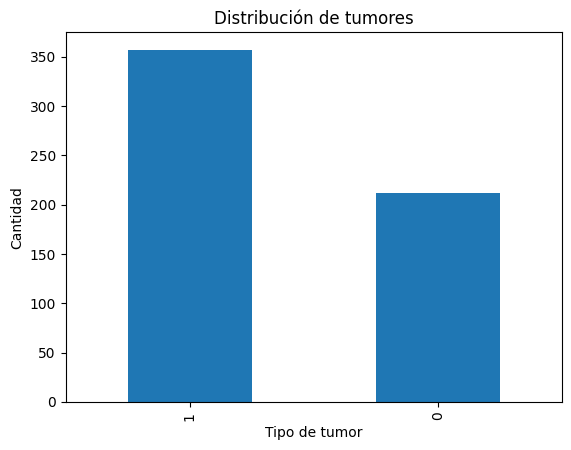

In [5]:
df["target"].value_counts().plot(kind="bar")

plt.title("Distribución de tumores")
plt.xlabel("Tipo de tumor")
plt.ylabel("Cantidad")

plt.show()

## 4. Exploratory Data Analysis

Before training machine learning models, we explore the dataset to understand:

- data structure
- missing values
- statistical distribution of variables
- relationships between features

This step is essential to detect potential issues and understand the biological meaning of the variables.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### Missing Values

We check whether the dataset contains missing values.
Missing data can affect model training and statistical analysis.

In [7]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

### Descriptive Statistics

We inspect the statistical distribution of each feature.

In [8]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### Class Labels

We convert the numeric target variable into human-readable labels.

In [9]:
df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})
df["diagnosis"].value_counts()

diagnosis
benign       357
malignant    212
Name: count, dtype: int64

### Feature Distribution

We inspect the distribution of some key tumor features.

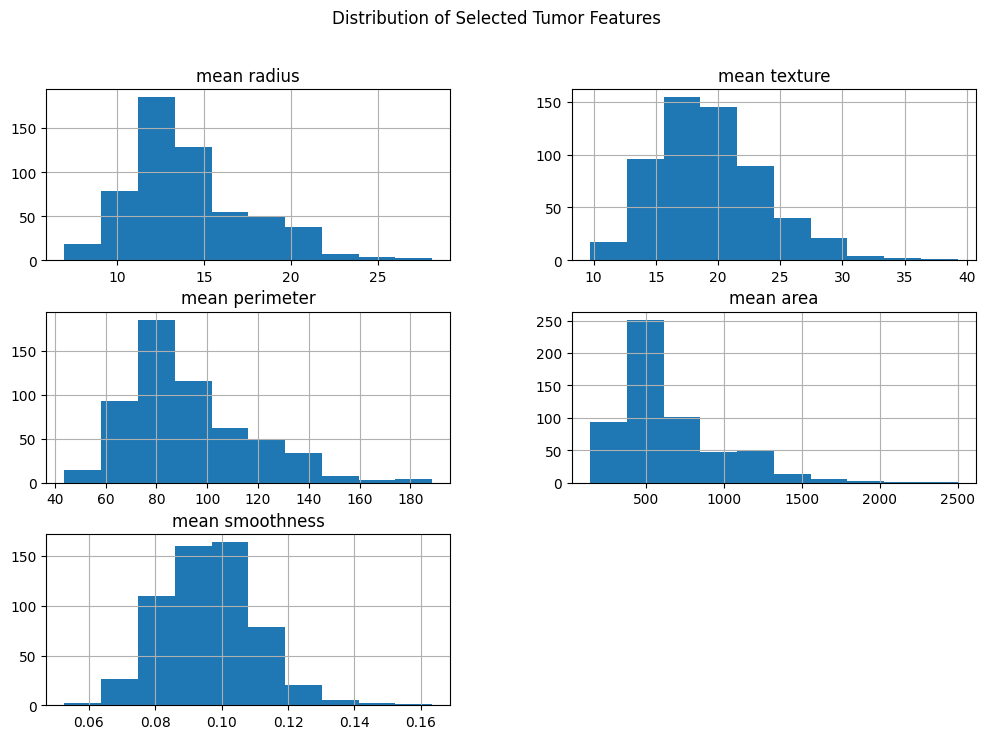

In [10]:
features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

df[features].hist(figsize=(12,8))
plt.suptitle("Distribution of Selected Tumor Features")
plt.show()

### Correlation Analysis

We examine correlations between tumor features.
Highly correlated features may contain redundant information.

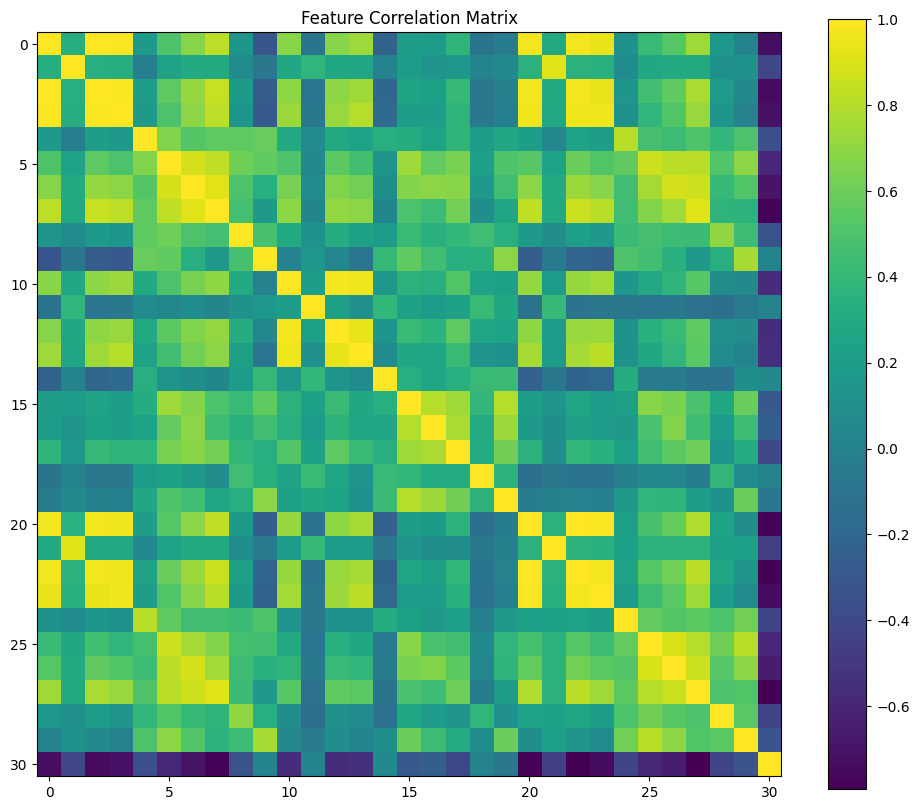

In [11]:
corr = df.drop(columns=["diagnosis"]).corr()

plt.figure(figsize=(12,10))
plt.imshow(corr)
plt.colorbar()

plt.title("Feature Correlation Matrix")
plt.show()

### Correlation with Diagnosis

We inspect which variables are most correlated with the target variable.

In [12]:
corr_target = corr["target"].sort_values()

print(corr_target.head(10))
print(corr_target.tail(10))

worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
worst area             -0.733825
mean radius            -0.730029
mean area              -0.708984
mean concavity         -0.696360
worst concavity        -0.659610
Name: target, dtype: float64
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0.008303
mean fractal dimension     0.012838
smoothness error           0.067016
target                     1.000000
Name: target, dtype: float64


### Correlation with Diagnosis

Several tumor features show strong correlation with the diagnosis variable.

The most strongly correlated features include:

- worst concave points
- worst perimeter
- mean concave points
- worst radius

These features are related to tumor size and irregularity, which are known indicators of malignancy in breast cancer pathology.

### PCA Visualization

Principal Component Analysis (PCA) helps visualize high-dimensional data in two dimensions.

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [17]:
pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])
pca_df["diagnosis"] = df["diagnosis"]

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

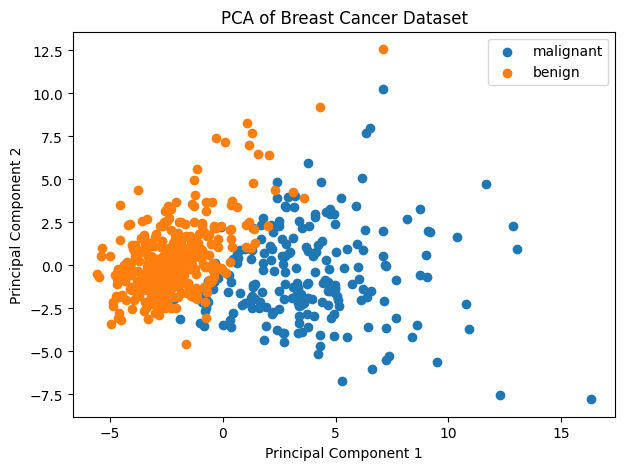

In [19]:
plt.figure(figsize=(7,5))

for diagnosis in pca_df["diagnosis"].unique():
    subset = pca_df[pca_df["diagnosis"] == diagnosis]
    plt.scatter(subset["PC1"], subset["PC2"], label=diagnosis)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Breast Cancer Dataset")
plt.legend()

plt.show()

### PCA Visualization

The PCA projection shows that benign and malignant tumors tend to occupy different regions of the feature space.

Although there is some overlap between the classes, a partial separation is visible, suggesting that the tumor features contain meaningful diagnostic information.


## 5. Machine Learning Models

In this section we train machine learning models to classify tumors as malignant or benign.

We will:

- split the dataset into training and testing sets
- train classification models
- evaluate their performance using accuracy, confusion matrix and ROC curves

In [20]:
X = df.drop(columns=["target","diagnosis"])
y = df["target"]


### Train-Test Split

We split the dataset into training and testing sets.

The training data is used to train the model, while the testing data is used to evaluate its performance on unseen samples.

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


### Feature Scaling

We scale the features so that each variable has mean 0 and standard deviation 1.

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Logistic Regression

Logistic regression is a common statistical model used in biomedical classification problems.

In [26]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=5000)

model_lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

In [27]:
y_pred_lr = model_lr.predict(X_test_scaled)


### Model Evaluation


In [28]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_lr)

0.9824561403508771

In [29]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_lr)

array([[41,  1],
       [ 1, 71]], dtype=int64)

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



### Model Performance

The logistic regression model achieved high classification performance on the test dataset.

The model reached an overall accuracy of **98%**, correctly classifying the majority of tumor samples.

For malignant tumors (class 0), the model achieved:

- Precision: 0.98
- Recall: 0.98
- F1-score: 0.98

For benign tumors (class 1), the model achieved:

- Precision: 0.99
- Recall: 0.99
- F1-score: 0.99

These results indicate that the model is highly effective at distinguishing malignant from benign tumors based on the extracted cellular features.

### ROC Curve

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score

In [32]:
y_prob_lr = model_lr.predict_proba(X_test_scaled)[:,1]


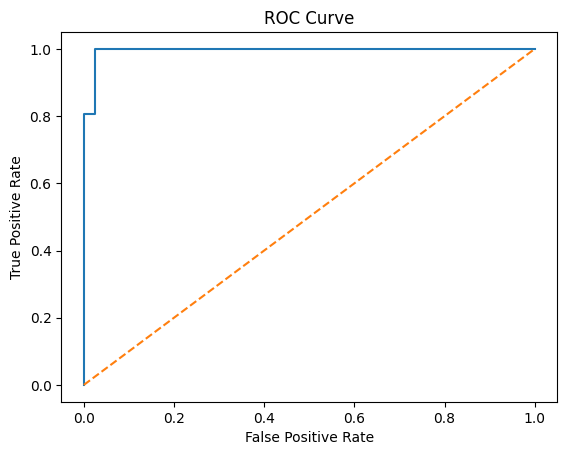

In [33]:
fpr, tpr, thresholds = roc_curve(y_test,y_prob_lr)

plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

### ROC Curve Analysis

The ROC curve evaluates the ability of the model to distinguish between malignant and benign tumors across different classification thresholds.

The area under the ROC curve (AUC) measures the overall performance of the classifier.

An AUC close to 1 indicates excellent discrimination ability, meaning that the model can effectively separate malignant and benign tumor samples.

In [34]:
roc_auc_score(y_test,y_prob_lr)

0.9953703703703703

## 6. Random Forest Model

In this section, we train a Random Forest classifier and compare its performance with logistic regression.

Random Forest is a tree-based machine learning model that can capture nonlinear relationships between features.

In [36]:
from sklearn.ensemble import RandomForestClassifier

In [37]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

### Predictions and Evaluation

In [38]:
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

In [39]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_rf

0.956140350877193

In [40]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf

array([[39,  3],
       [ 2, 70]], dtype=int64)

In [41]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



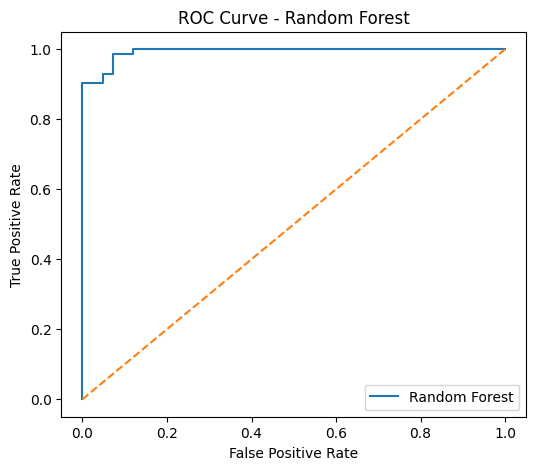

In [42]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.savefig("../figures/roc_curve_random_forest.png", dpi=300)
plt.show()

In [43]:
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_rf

0.9930555555555556

### Model Comparison

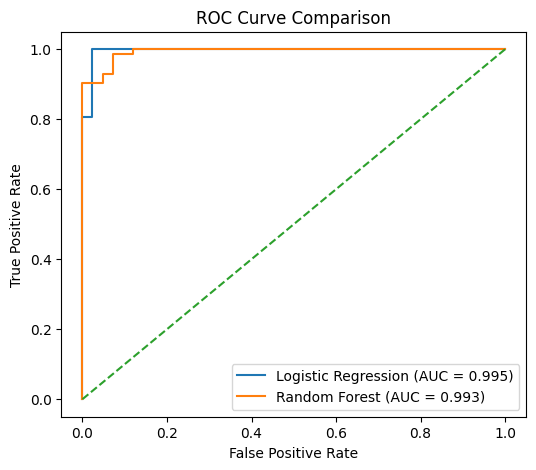

In [44]:
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig("../figures/roc_curve_comparison.png", dpi=300)
plt.show()

## 7. Feature Importance

Random Forest allows us to estimate the relative importance of each feature for classification.

This helps identify which tumor characteristics are most informative for distinguishing malignant and benign cases.

In [45]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model_rf.feature_importances_
})

feature_importance = feature_importance.sort_values("importance", ascending=False)
feature_importance.head(10)

,feature,importance
22,worst perimeter,0.133100
23,worst area,0.128052
27,worst concave points,0.108107
7,mean concave points,0.094414
20,worst radius,0.090639
0,mean radius,0.058662
2,mean perimeter,0.055242
3,mean area,0.049938
6,mean concavity,0.046207
26,worst concavity,0.035357


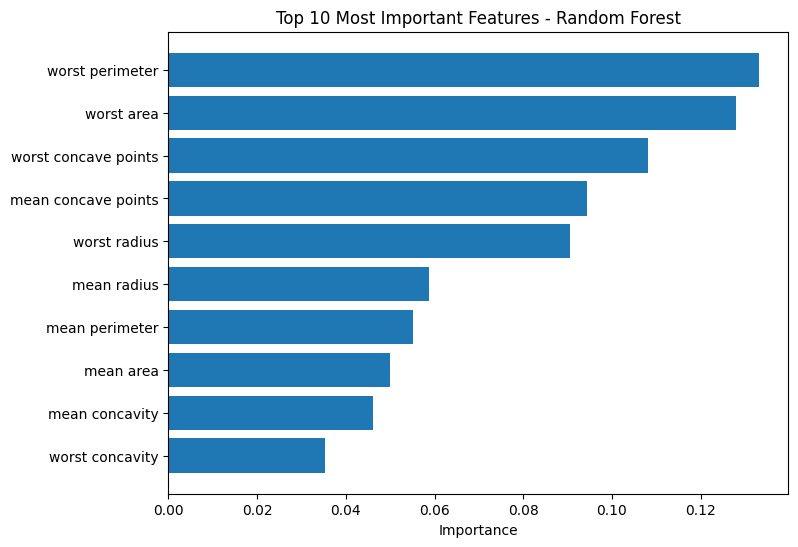

In [46]:
top10 = feature_importance.head(10).sort_values("importance")

plt.figure(figsize=(8,6))
plt.barh(top10["feature"], top10["importance"])

plt.xlabel("Importance")
plt.title("Top 10 Most Important Features - Random Forest")

plt.savefig("../figures/top10_feature_importance_rf.png", dpi=300)
plt.show()

### Feature Importance Interpretation

The Random Forest model identified several tumor size and shape features as the most informative predictors.

The most important variables include:

- worst perimeter
- worst area
- worst concave points
- mean concave points
- worst radius

These features describe tumor size and boundary irregularity, which are known morphological indicators of malignancy in breast cancer pathology.

This result is consistent with clinical knowledge, since malignant tumors tend to exhibit larger size and more irregular shapes compared with benign tumors.

In [47]:
feature_importance.to_csv("../results/random_forest_feature_importance.csv", index=False)

## 8. Summary of Model Performance

Both Logistic Regression and Random Forest achieved excellent classification performance on the breast cancer dataset.

The high accuracy and AUC values indicate that the extracted cellular features provide strong diagnostic information for distinguishing malignant from benign tumors.

In addition, the Random Forest feature importance analysis suggests that variables related to tumor size and boundary irregularity play a central role in classification.

## Final Conclusion

This project explored the Breast Cancer Wisconsin dataset to classify tumors as malignant or benign using machine learning techniques.

Two models were evaluated: Logistic Regression and Random Forest.

Logistic Regression achieved the best performance, with an accuracy of approximately **98%**, while the Random Forest model achieved an accuracy of **96%** and an AUC of **0.99**.

Both models performed extremely well, indicating that the tumor morphometric features contain strong predictive information.

The feature importance analysis from the Random Forest model revealed that variables related to tumor size and shape irregularity were the most informative predictors. In particular:

- worst perimeter
- worst area
- worst concave points
- mean concave points
- worst radius

These findings are consistent with medical knowledge, as malignant tumors tend to exhibit larger sizes and more irregular shapes compared to benign tumors.

Overall, this analysis demonstrates that machine learning models can effectively distinguish malignant from benign tumors using morphometric features extracted from medical images.